In [1]:
import pandas as pd

from sklearn.datasets import load_iris

# Load dataset
iris = load_iris()

# Create dataframe
df = pd.DataFrame(iris.data, columns=iris.feature_names)

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

print(scaled_data[:5])

[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]


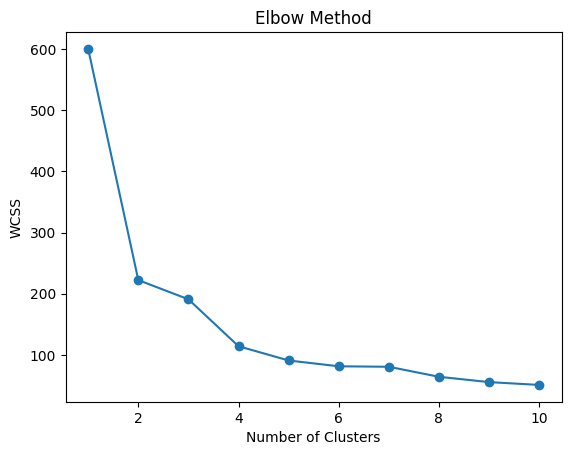

In [3]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):

    kmeans = KMeans(n_clusters=k, random_state=42)

    kmeans.fit(scaled_data)

    wcss.append(kmeans.inertia_)

# Plot elbow graph
plt.plot(range(1, 11), wcss, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

In [4]:
# Create KMeans model
kmeans = KMeans(n_clusters=3, random_state=42)

# Fit model
clusters = kmeans.fit_predict(scaled_data)

# Add clusters to dataframe
df['Cluster'] = clusters

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Cluster  
0        1  
1        2  
2        2  
3        2  
4        1  


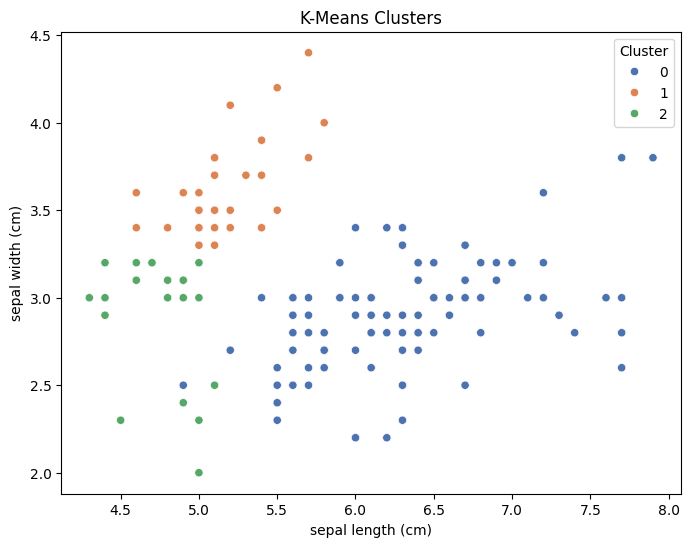

In [5]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df.iloc[:,0],
    y=df.iloc[:,1],
    hue=df['Cluster'],
    palette='deep'
)

plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])

plt.title("K-Means Clusters")

plt.show()

In [6]:
# Cluster counts
print(df['Cluster'].value_counts())

# Cluster centers
print(kmeans.cluster_centers_)

Cluster
0    96
1    33
2    21
Name: count, dtype: int64
[[ 0.57100359 -0.37176778  0.69111943  0.66315198]
 [-0.81623084  1.31895771 -1.28683379 -1.2197118 ]
 [-1.32765367 -0.373138   -1.13723572 -1.11486192]]
